### SEC Filing Analyzer: Chunking Strategy & Model Comparison Study
**STAT 453 — Group 17 | Spring 2026**


we treat the RAG pipeline as an experiment. We hold the dataset constant (SEC 10-K filings, same companies and years) and systematically vary two things: how we split the documents into chunks, and which language model generates the answer. Then we measure each combination along several dimensions that match what we described in our proposal.

**Research Question:** For dense financial documents like SEC 10-K filings, which combination of text chunking strategy and generative model produces the most accurate, grounded, and faithful answers to natural language questions?

**Experimental variables:**
- **Chunking Strategy (3 methods):** Fixed-Size (token-level baseline), Sentence-Aware (respects sentence boundaries), Paragraph-Based (natural document structure), Sliding Window (high overlap)
- **Generative Model (2 models):** Ollama llama3.2:3b (free, local), OpenAI GPT-4o-mini (API)
- **Embedding Model:** `all-MiniLM-L6-v2` held constant across all conditions (fair comparison)

**Evaluation Metrics (directly from our proposal):**
1. Retrieval Precision@k — fraction of top-k chunks from the correct section
2. Hit Rate@k — did the correct section appear anywhere in top-k?
3. Mean Reciprocal Rank (MRR) — how high does the first correct chunk rank?
4. Answer Faithfulness — does the generated answer stay grounded in retrieved context?
5. Answer Relevance — does the answer actually address what was asked?
6. End-to-End Latency — how long does each model take to respond?

---
## 0. Setup & Environment

Install all the libraries we need. We add `openai` since we're now comparing against those APIs, and `nltk` for the sentence tokenizer we use in one of our chunking methods.

In [1]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4 lxml tiktoken tqdm chromadb sentence-transformers ollama openai anthropic nltk -q
print("All dependencies installed.")

All dependencies installed.


In [2]:
import os, sys, json, time, re, logging, warnings, uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from getpass import getpass
import nltk

# Download NLTK data for sentence tokenization
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

logging.basicConfig(format="%(asctime)s  %(levelname)-8s  %(name)s — %(message)s",
                    datefmt="%H:%M:%S", level=logging.INFO)
for lib in ["urllib3", "requests", "httpx", "openai", "chromadb",
            "sentence_transformers", "anthropic", "huggingface_hub"]:
    logging.getLogger(lib).setLevel(logging.WARNING)

warnings.filterwarnings("ignore")
print("Imports ready. Project root:", PROJECT_ROOT)

Imports ready. Project root: C:\Users\dinsa\OneDrive - UW-Madison\Documents\AA CLASS NOTES\SPRING 2026\STAT453\FINAL_PROJECT_STAT453


### API Key Configuration

Since we're working with three model providers. Ollama runs completely locally (no key needed), but OpenAI and Anthropic require API credentials. We read them from environment variables so they never get committed to the repo. If the variable isn't set, `getpass` will prompt for it at runtime.

If you're running this without API access, flip `USE_OPENAI = False` and/or `USE_CLAUDE = False` below — the retrieval evaluation (Section 6) still runs fully without them, and you'll just skip those columns in the generation comparison.

In [3]:
# Models — Claude Haiku removed per Consultation 2 recommendation
USE_OPENAI   = True
USE_OLLAMA   = True

OLLAMA_MODEL = "llama3.2:3b"
OPENAI_MODEL = "gpt-4o-mini"
EMBED_MODEL  = "sentence-transformers/all-MiniLM-L6-v2"

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
if USE_OPENAI and not OPENAI_API_KEY:
    OPENAI_API_KEY = getpass("OpenAI API key: ")
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("Configuration loaded:")
print(f"  Ollama  : {'enabled' if USE_OLLAMA else 'disabled'}  ({OLLAMA_MODEL})")
print(f"  OpenAI  : {'enabled' if USE_OPENAI else 'disabled'}  ({OPENAI_MODEL})")
print(f"  Embedding: {EMBED_MODEL}")

OpenAI API key:  ········


Configuration loaded:
  Ollama  : enabled  (llama3.2:3b)
  OpenAI  : enabled  (gpt-4o-mini)
  Embedding: sentence-transformers/all-MiniLM-L6-v2


---
## 1. Data Ingestion [ Shared Across All Experiments ]

We fetch the 10-K HTML from SEC EDGAR and extract the five named sections (Item 1 through Item 8) using BeautifulSoup. The raw section text is then the input to each of our four chunking strategies. Keeping ingestion identical across all experimental conditions is important: any differences we observe downstream can only be attributed to chunking or model choice, not to how the text was parsed.

As a beginnning, we will focus on small size of companies and most of our evaluation we work with the TSLA 2023 filing, since it's a well-known company with clearly written sections across all five items. We'll note when we expand to other filings.)

| Item | Section Name | We Extract? |
|---|---|---|
| Item 1 | Business | ✓ |
| Item 1A | Risk Factors | ✓ |
| Item 1B | Unresolved Staff Comments | ✗ |
| Item 2 | Properties | ✗ |
| Item 3 | Legal Proceedings | ✗ |
| Item 4 | Mine Safety Disclosures | ✗ |
| Item 5 | Market for Registrant's Common Equity | ✗ |
| Item 6 | Reserved | ✗ |
| Item 7 | Management Discussion and Analysis | ✓ |
| Item 7A | Quantitative and Qualitative Disclosures About Market Risk | ✓ |
| Item 8 | Financial Statements and Supplementary Data | ✓ |


Since we're going to act as financial analyst, we only pick 5 things to cover.

The 5 we extract cover the core information a financial analyst actually needs:

- Item 1 → what the company does
- Item 1A → what could go wrong
- Item 7 → how did they actually perform
- Item 7A → what market risks do they carry
- Item 8 → the raw numbers to back it all up

In [4]:
from config import COMPANIES, FILING_YEARS, TARGET_SECTIONS, CHROMA_DIR
from ingestion.edgar_fetcher import fetch_ticker
from ingestion.section_parser import parse_file

TICKER = "TSLA"
YEAR   = 2023

# fetch_ticker handles caching — if the HTML is already downloaded, it reuses it
records  = fetch_ticker(TICKER, years=[YEAR])
record   = records[0]
sections = parse_file(record["local_path"])

print(f"Filing  : {record['ticker']} {record['year']}  |  {record['filing_date']}")
print(f"Accession: {record['accession_number']}")
print(f"\nSections extracted:")
for key, text in sections.items():
    label = TARGET_SECTIONS.get(key, key)
    print(f"  {key:10s}  {len(text):>9,} chars  |  {label}")

15:12:19  INFO      ingestion.edgar_fetcher — Already downloaded: TSLA_2023_000095017023001409.htm
15:12:23  INFO      ingestion.section_parser — Extracted item_1: 42165 chars
15:12:23  INFO      ingestion.section_parser — Extracted item_1a: 82556 chars
15:12:23  INFO      ingestion.section_parser — Extracted item_7: 56318 chars
15:12:23  INFO      ingestion.section_parser — Extracted item_7a: 1692 chars
15:12:24  INFO      ingestion.section_parser — Extracted item_8: 174627 chars


Filing  : TSLA 2023  |  2023-01-31
Accession: 0000950170-23-001409

Sections extracted:
  item_1         42,165 chars  |  Business
  item_1a        82,556 chars  |  Risk Factors
  item_7         56,318 chars  |  Management Discussion and Analysis
  item_7a         1,692 chars  |  Quantitative and Qualitative Disclosures About Market Risk
  item_8        174,627 chars  |  Financial Statements


## 1b. HTML Table Extraction

Consultation recommendation: The main accuracy gap vs. published baselines (Jimeno-Yepes 33%) is that competitors read full PDFs including financial tables, while our previous pipeline extracted only text sections. Financial tables contain most of the numerical answers that hard questions test which has low accuracy on previous model.

We now extract tables from the raw HTML filing and convert them to structured text chunks. These are added to the indexing pipeline alongside the regular section chunks.

In [5]:
from bs4 import BeautifulSoup

def extract_html_tables(html_path: str, min_rows: int = 3, min_cols: int = 2) -> list:
    """
    Parse all <table> elements from a 10-K HTML filing and return them as
    plain-text chunks. Tables with fewer than min_rows or min_cols are skipped
    (likely navigation or formatting elements, not financial data).
    """
    with open(html_path, encoding="utf-8", errors="replace") as f:
        soup = BeautifulSoup(f.read(), "lxml")

    table_chunks = []
    for tbl_idx, table in enumerate(soup.find_all("table")):
        rows = []
        for tr in table.find_all("tr"):
            cells = [td.get_text(" ", strip=True) for td in tr.find_all(["td", "th"])]
            cells = [c for c in cells if c]  # drop empty cells
            if cells:
                rows.append(cells)

        if len(rows) < min_rows:
            continue
        max_cols = max(len(r) for r in rows)
        if max_cols < min_cols:
            continue

        # Convert rows to a readable text block
        lines = [" | ".join(r) for r in rows]
        table_text = "\n".join(lines)

        table_chunks.append({
            "text": table_text,
            "token_count":   len(table_text.split()),
            "method":        "table_extraction",
            "chunk_index":   tbl_idx,
            "total_chunks":  0,  # back-filled below
            "ticker":        TICKER,
            "year":          str(YEAR),
            "section_key":   "item_8",
            "section_label": "Financial Statements (Table)",
        })

    for c in table_chunks:
        c["total_chunks"] = len(table_chunks)

    return table_chunks


table_chunks = extract_html_tables(record["local_path"])
print(f"Extracted {len(table_chunks)} financial tables from HTML filing.")
if table_chunks:
    sample = table_chunks[0]
    print(f"\nSample table (first 300 chars):")
    print(sample["text"][:300])

Extracted 81 financial tables from HTML filing.

Sample table (first 300 chars):
Large accelerated filer | ☒ | Accelerated filer | ☐
Non-accelerated filer | ☐ | Smaller reporting company | ☐
Emerging growth company | ☐


---
## 2. Chunking Strategies 

Chunking is the process of splitting long documents into smaller pieces that can be individually embedded and retrieved. It turns out this decision has a significant impact on retrieval quality, and it's surprisingly under-studied for financial documents specifically.

The core tension is: if chunks are too large, the embedding becomes a "soup" that captures many different topics and retrieves weakly; if chunks are too small, individual chunks lack enough context to be useful when surfaced to the LLM. There's also the question of whether splitting on token counts (ignoring text structure) is worse than splitting on natural linguistic boundaries.

We implement four strategies:

| # | Strategy | Core Idea | 
|---|---|---|
| 1 | **Fixed-Size (Token-Level)** | Split every N tokens regardless of sentence/paragraph — naive baseline | 
| 2 | **Sentence-Aware** | Group sentences greedily until token limit; respects sentence boundaries | 
| 3 | **Paragraph-Based** | Split on double newlines (natural breaks in SEC filings); merge short paras | 
| 4 | **Sliding Window** | Fixed-size but with 50% overlap — each chunk shares context with neighbors | 

**Hypothesis:** We expect sentence-aware and paragraph-based methods to produce better retrieval precision because SEC filings are written with clear paragraph structure, and splitting mid-sentence should hurt semantic coherence of the embedding.

In [6]:
import tiktoken
from nltk.tokenize import sent_tokenize

TOKENIZER = tiktoken.get_encoding("cl100k_base")

def _count_tokens(text: str) -> int:
    return len(TOKENIZER.encode(text))


# Strategy 1: Fixed-Size (Token-Level) 
def chunk_fixed_size(text: str, chunk_size: int = 500, overlap: int = 50, **meta) -> list:

    tokens = TOKENIZER.encode(text)
    chunks = []
    i = 0
    chunk_idx = 0
    
    # Slide a window across the token list until we reach the end of the text
    while i < len(tokens):
        window     = tokens[i: i + chunk_size]
        chunk_text = TOKENIZER.decode(window)

        # Store the chunk along with its metadata (ticker, year, section, etc.)
        chunks.append({
            "text":        chunk_text,
            "token_count": len(window),
            "method":      "fixed_size",
            "chunk_index": chunk_idx,
            **meta
        })
        i += chunk_size - overlap
        chunk_idx += 1

    # Now that we know the final count, back-fill total_chunks into every chunk
    for c in chunks:
        c["total_chunks"] = len(chunks)
    return chunks

In [7]:
#  Strategy 2: Sentence-Aware 
def chunk_sentence_aware(text: str, max_tokens: int = 450, overlap_sents: int = 2, **meta) -> list:
    """
    Split text by sentences (using NLTK), then group them into chunks.
    Keeps last 2 sentences of each chunk as overlap for the next one.
    This avoids cutting mid-sentence which hurts embedding quality.
    """
    sentences = sent_tokenize(text)
    if not sentences:
        return []

    chunks, buffer = [], []

    def flush(buf):
        if not buf:
            return
        chunk_text = " ".join(buf)
        chunks.append({
            "text":        chunk_text,
            "token_count": _count_tokens(chunk_text),
            "method":      "sentence_aware",
            "chunk_index": len(chunks),
            **meta
        })

    for sent in sentences:
        # Count how many tokens this sentence has
        st = _count_tokens(sent)
        # Count how many tokens are currently sitting in the buffer
        current_tok = _count_tokens(" ".join(buffer)) if buffer else 0

        # If adding this sentence would exceed the limit, save the buffer as a chunk
        if current_tok + st > max_tokens and buffer:
            flush(buffer)

            # Start the new buffer with the last 2 sentences + current sentence
            # This way the next chunk has some context from the previous one
            buffer = buffer[-overlap_sents:] + [sent]

        # Otherwise just add the sentence into the buffer and keep going
        else:
            buffer.append(sent)
    flush(buffer)

    for c in chunks:
        c["total_chunks"] = len(chunks)
    return chunks

In [8]:
#  Strategy 3: Paragraph-Based 
def chunk_paragraph_based(text: str, min_tokens: int = 50, max_tokens: int = 600, **meta) -> list:
    """
    Split the section on paragraph breaks (sequences of 2+ newlines).
    SEC filings tend to have well-structured paragraphs — numbered risk factors,
    financial discussion bullets, etc. — so this respects that natural structure.
    Short paragraphs (<min_tokens) get merged with the next one; long ones
    (>max_tokens) get split further using sentence boundaries.
    """
    raw_paras = [p.strip() for p in re.split(r"\n{2,}", text) if p.strip()]
    chunks, buffer, buf_tok = [], [], 0

    def flush(buf):
        if not buf:
            return
        chunk_text = "\n\n".join(buf)
        chunks.append({
            "text":        chunk_text,
            "token_count": _count_tokens(chunk_text),
            "method":      "paragraph_based",
            "chunk_index": len(chunks),
            **meta
        })

    for para in raw_paras:
        pt = _count_tokens(para)
        if pt > max_tokens:
            # Para is too long — flush current buffer then split this para by sentences
            if buffer:
                flush(buffer)
                buffer, buf_tok = [], 0
            sents = sent_tokenize(para)
            sub_buf, sub_tok = [], 0
            for s in sents:
                st = _count_tokens(s)
                if sub_tok + st > max_tokens and sub_buf:
                    chunk_text = " ".join(sub_buf)
                    chunks.append({
                        "text": chunk_text, "token_count": _count_tokens(chunk_text),
                        "method": "paragraph_based", "chunk_index": len(chunks), **meta
                    })
                    sub_buf, sub_tok = [s], st
                else:
                    sub_buf.append(s); sub_tok += st
            if sub_buf:
                chunk_text = " ".join(sub_buf)
                chunks.append({
                    "text": chunk_text, "token_count": _count_tokens(chunk_text),
                    "method": "paragraph_based", "chunk_index": len(chunks), **meta
                })
        elif pt < min_tokens:
            # Too short — merge into buffer
            buffer.append(para); buf_tok += pt
        elif buf_tok + pt > max_tokens:
            flush(buffer)
            buffer, buf_tok = [para], pt
        else:
            buffer.append(para); buf_tok += pt

    flush(buffer)
    for c in chunks:
        c["total_chunks"] = len(chunks)
    return chunks

In [9]:
#  Strategy 4: Sliding Window (High Overlap) 
def chunk_sliding_window(text: str, chunk_size: int = 300, overlap: int = 150, **meta) -> list:
    """
    Similar to fixed-size but with 50% overlap between consecutive windows.
    The idea is that important context sitting at a chunk boundary under
    fixed-size splitting will be fully captured in at least one of the
    overlapping windows here. The cost is more chunks (and more vectors to store).
    """
    tokens = TOKENIZER.encode(text)
    chunks = []
    i, chunk_idx = 0, 0
    while i < len(tokens):
        window     = tokens[i: i + chunk_size]
        chunk_text = TOKENIZER.decode(window)
        chunks.append({
            "text":        chunk_text,
            "token_count": len(window),
            "method":      "sliding_window",
            "chunk_index": chunk_idx,
            **meta
        })
        i += chunk_size - overlap
        chunk_idx += 1
    for c in chunks:
        c["total_chunks"] = len(chunks)
    return chunks

In [10]:
CHUNKERS = {
    "fixed_size":      chunk_fixed_size,
    "sentence_aware":  chunk_sentence_aware,
    "paragraph_based": chunk_paragraph_based,
    "sliding_window":  chunk_sliding_window,
}

print("All chunking strategies defined:")
for name in CHUNKERS:
    print(f"  • {name}")

All chunking strategies defined:
  • fixed_size
  • sentence_aware
  • paragraph_based
  • sliding_window


### Applying All Four Strategies to the Same Sections

We run each chunker on the five parsed sections from our TSLA 2023 filing. The summary table below shows how they differ in chunk count and token distribution, which already hints at what we might observe in retrieval.

In [11]:
chunk_results = {}  # method_name -> list of chunk dicts

for method_name, chunker_fn in CHUNKERS.items():
    all_chunks = []
    for section_key, section_text in sections.items():
        meta = {
            "ticker":        TICKER,
            "year":          str(YEAR),
            "section_key":   section_key,
            "section_label": TARGET_SECTIONS.get(section_key, section_key),
        }
        chunk_list = chunker_fn(section_text, **meta)
        all_chunks.extend(chunk_list)
    chunk_results[method_name] = all_chunks

# Print comparison table
print(f"{'Chunking Method':<22} {'# Chunks':>9} {'Avg Tokens':>11} {'Min':>6} {'Median':>8} {'Max':>6}")
print("─" * 66)
for method, chunks in chunk_results.items():
    toks = [c["token_count"] for c in chunks]
    print(f"{method:<22} {len(chunks):>9} {np.mean(toks):>11.1f} "
          f"{min(toks):>6} {int(np.median(toks)):>8} {max(toks):>6}")

Chunking Method         # Chunks  Avg Tokens    Min   Median    Max
──────────────────────────────────────────────────────────────────
fixed_size                   159       490.5     46      500    500
sentence_aware               223       451.7     72      432   1155
paragraph_based              126       557.9     23      580    985
sliding_window               471       296.9     24      300    300


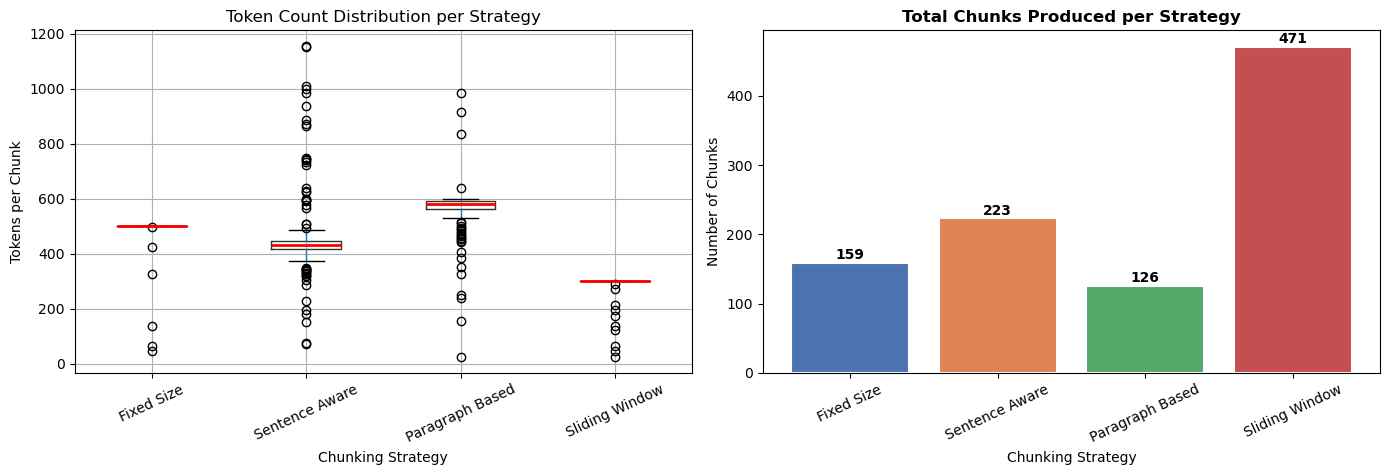

Saved: chunk_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

#  Left: token distribution per strategy 
data_rows = []
for method, chunks in chunk_results.items():
    label = method.replace("_", " ").title()
    for c in chunks:
        data_rows.append({"Strategy": label, "Tokens": c["token_count"]})
df_dist = pd.DataFrame(data_rows)

strategies_ordered = [m.replace("_", " ").title() for m in CHUNKERS]
df_dist["Strategy"] = pd.Categorical(df_dist["Strategy"], categories=strategies_ordered, ordered=True)
df_dist.boxplot(column="Tokens", by="Strategy", ax=axes[0],
                boxprops=dict(color="#333"), medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Token Count Distribution per Strategy", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Chunking Strategy")
axes[0].set_ylabel("Tokens per Chunk")
axes[0].tick_params(axis="x", rotation=25)
plt.sca(axes[0]); plt.title("Token Count Distribution per Strategy")

#  Right: total chunk count per strategy 
counts = {m.replace("_", " ").title(): len(c) for m, c in chunk_results.items()}
bars   = axes[1].bar(counts.keys(), counts.values(), color=palette, edgecolor="white", linewidth=1.5)
axes[1].set_title("Total Chunks Produced per Strategy", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Chunking Strategy")
axes[1].set_ylabel("Number of Chunks")
axes[1].tick_params(axis="x", rotation=25)
for bar, v in zip(bars, counts.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                 str(v), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("")
plt.tight_layout()
plt.savefig("chunk_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: chunk_distribution.png")

---
## 3. Indexing — One ChromaDB Collection per Strategy

For the ablation to be valid, each chunking strategy needs its own isolated vector store. If we mixed chunks from different strategies in the same collection, any retrieval difference could be explained by cross-contamination rather than chunking quality.

We create four separate ChromaDB collections to avoid messing up and mixing up from each chunking strategy with one per strategy, each embedded with the same `all-MiniLM-L6-v2` model. Holding the embedding model constant is what makes the comparison fair. the only thing changing is how the source text was segmented before embedding, not how the resulting text was encoded.

In [13]:
import chromadb
from sentence_transformers import SentenceTransformer

print("Loading embedding model")
embed_model = SentenceTransformer(EMBED_MODEL)
print(f"Embedding model ready: {EMBED_MODEL}\n")

EVAL_CHROMA_DIR = os.path.join(CHROMA_DIR, "eval_study")
os.makedirs(EVAL_CHROMA_DIR, exist_ok=True)
chroma_client = chromadb.PersistentClient(path=EVAL_CHROMA_DIR)


def make_chunk_id(chunk: dict) -> str:
    return (f"{chunk.get('ticker','')}_{chunk.get('year','')}_{chunk.get('method','')}_{chunk.get('section_key','')}_{chunk.get('chunk_index', 0)}")


def index_chunks_into_collection(collection, chunks: list, batch_size: int = 64):
    existing_ids = set(collection.get()["ids"])
    new_chunks   = [c for c in chunks if make_chunk_id(c) not in existing_ids]
    if not new_chunks:
        print(f"- All {len(chunks)} chunks already indexed.")
        return
    texts    = [c["text"] for c in new_chunks]
    ids      = [make_chunk_id(c) for c in new_chunks]
    metadatas = [
        {k: str(v) for k, v in c.items() if k != "text"}
        for c in new_chunks
    ]
    for start in range(0, len(texts), batch_size):
        batch_t  = texts[start: start + batch_size]
        batch_id = ids[start: start + batch_size]
        batch_m  = metadatas[start: start + batch_size]
        emb      = embed_model.encode(batch_t, show_progress_bar=False).tolist()
        collection.upsert(ids=batch_id, embeddings=emb,
                          documents=batch_t, metadatas=batch_m)
    print(f"- Indexed {len(new_chunks)} new chunks  (collection total: {collection.count()})")


# Build one collection per chunking strategy
collections = {}
for method_name, chunks in chunk_results.items():
    col_name = f"sec_eval_{method_name}"
    print(f"Collection: {col_name}  ({len(chunks)} chunks)")
    col = chroma_client.get_or_create_collection(
        name=col_name, metadata={"hnsw:space": "cosine"}
    )
    index_chunks_into_collection(col, chunks)
    collections[method_name] = col

print("\nAll collections ready:")
print(f"{'Method':<22}  {'Vectors':>8}")
print("─" * 34)
for name, col in collections.items():
    print(f"  {name:<20}  {col.count():>8}")

Loading embedding model


15:12:43  WARNING   huggingface_hub.utils._http — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 2036.01it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model ready: sentence-transformers/all-MiniLM-L6-v2

Collection: sec_eval_fixed_size  (159 chunks)
- All 159 chunks already indexed.
Collection: sec_eval_sentence_aware  (223 chunks)
- All 223 chunks already indexed.
Collection: sec_eval_paragraph_based  (126 chunks)
- All 126 chunks already indexed.
Collection: sec_eval_sliding_window  (471 chunks)
- All 471 chunks already indexed.

All collections ready:
Method                   Vectors
──────────────────────────────────
  fixed_size                 159
  sentence_aware             223
  paragraph_based            126
  sliding_window             471


---
## 4. Generative Model Setup

With our indexed collections in place, we now configure the three language model backends. Each one receives the exact same prompt template, which keeps the generation comparison as controlled as possible. The prompt follows the structure from our proposal: a strict grounding instruction, numbered context passages, and a citation requirement.

**Ollama (llama3.2:3b):** A 3-billion parameter open model running locally via Ollama. No API costs, no data leaves the machine. Performance is limited by the model size and by running on CPU, but it gives us a free, fully transparent baseline.

**OpenAI GPT-4o-mini:** A smaller, cheaper variant of GPT-4o accessed via the OpenAI API. Significantly stronger than llama3.2 at following complex instructions and synthesizing information across multiple retrieved passages.

In [14]:
if USE_OPENAI:
    from openai import OpenAI as _OAI
    _openai_client = _OAI(api_key=OPENAI_API_KEY)

if USE_OLLAMA:
    import ollama as _ollama

SYSTEM_PROMPT = (
    "You are a senior financial analyst assistant specializing in SEC filings (10-K, 10-Q). "
    "Your task is to answer user questions using ONLY the information provided in the numbered "
    "context passages below.\n\n"
    "IMPORTANT RULES:\n"
    "1. Use ONLY the provided context. Do not use outside knowledge.\n"
    "2. Cite every factual claim using [1], [2], etc. matching passage numbers.\n"
    "3. If the answer is not fully supported by the context, explicitly state what is missing.\n"
    "4. Do NOT hallucinate numbers, risks, or business explanations.\n"
    "5. Prefer quoting key phrases from the filings when useful.\n\n"
    "Provide your response using the following structured financial analysis format:\n\n"
    "---\n"
    "[ Executive Summary ]\n"
    "Provide a 2-4 sentence high-level answer to the user's question.\n\n"
    "[ Key Findings ]\n"
    "- Bullet point summary of the most important facts\n"
    "- Each bullet must include citation(s) [1], [2]\n\n"
    "[ Financial or Business Drivers ]\n"
    "Explain the underlying reasons mentioned in the filings.\n\n"
    "[ Risk Factors (if applicable) ]\n"
    "List relevant risks mentioned in the filings with citations.\n\n"
    "[ Supporting Evidence from Filings ]\n"
    "Provide short quoted excerpts with citations.\n\n"
    "[ Limitations / Missing Information ]\n"
    "Explicitly state if the retrieved context is incomplete.\n\n"
    "---\n"
    "Answer professionally, concisely, and in an objective financial analyst tone."
)

def _build_user_message(question: str, context: str) -> str:
    return f"Context passages:\n\n{context}\n\n---\n\nQuestion: {question}\n\nAnswer (with citations):"

def format_context(chunks: list) -> str:
    parts = []
    for i, c in enumerate(chunks, 1):
        header = (f"[{i}] {c.get('ticker','')} {c.get('year','')} | "
                  f"{c.get('section_label', 'Unknown')} (chunk {c.get('chunk_index','?')})")
        parts.append(f"{header}\n{c['text']}")
    return "\n\n---\n\n".join(parts)


def generate_with_ollama(question: str, context: str) -> tuple:
    if not USE_OLLAMA:
        return "Ollama disabled.", 0.0
    prompt = _build_user_message(question, context)
    t0 = time.time()
    try:
        resp   = _ollama.chat(
            model=OLLAMA_MODEL,
            messages=[{"role": "system", "content": SYSTEM_PROMPT},
                      {"role": "user",   "content": prompt}],
            options={"temperature": 0.1},
        )
        answer = resp["message"]["content"].strip()
    except Exception as e:
        answer = f"[Ollama error: {e}]"
    return answer, round(time.time() - t0, 2)


def generate_with_openai(question: str, context: str) -> tuple:
    if not USE_OPENAI:
        return "OpenAI disabled.", 0.0
    prompt = _build_user_message(question, context)
    t0 = time.time()
    try:
        resp   = _openai_client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[{"role": "system", "content": SYSTEM_PROMPT},
                      {"role": "user",   "content": prompt}],
            temperature=0.1, max_tokens=600,
        )
        answer = resp.choices[0].message.content.strip()
    except Exception as e:
        answer = f"[OpenAI error: {e}]"
    return answer, round(time.time() - t0, 2)


GENERATORS = {}
if USE_OLLAMA: GENERATORS["Ollama"] = generate_with_ollama
if USE_OPENAI: GENERATORS["OpenAI"] = generate_with_openai

print(f"Active generators: {list(GENERATORS.keys())}")

Active generators: ['Ollama', 'OpenAI']


### Quick Test Before Full Evaluation

Before running the full evaluation, we do a quick sanity check to make sure each backend is responding correctly.

In [15]:
test_ctx = (
    "[1] TSLA 2023 | Risk Factors (chunk 2):\n"
    "Tesla faces intense competition from both established automakers transitioning to EVs "
    "and newer EV-only entrants. Pricing pressure has intensified as competitors have "
    "expanded their model lineups and reduced prices."
)
test_q = "What competitive risks does Tesla face?"

print("=== Test ===\n")
for model_name, gen_fn in GENERATORS.items():
    answer, latency = gen_fn(test_q, test_ctx)
    print(f"[{model_name}]  ({latency:.1f}s)")
    print(answer[:250])
    print()

=== Test ===

[Ollama]  (4.7s)
---
[ Executive Summary ]
Tesla faces intense competition in the electric vehicle market, with established automakers transitioning to EVs and newer EV-only entrants posing a threat. This competition is driven by pricing pressure as competitors expan

[OpenAI]  (5.4s)
---
[ Executive Summary ]
Tesla faces significant competitive risks primarily due to intense competition from both established automakers transitioning to electric vehicles (EVs) and newer EV-only entrants. This competition has led to increased prici



---
**Consultation recommendation:** Replace the keyword-overlap faithfulness proxy with a proper LLM-as-judge approach. So, we now use GPT-4o-mini rates each generated answer on a 0.0–1.0 faithfulness scale given the question and the retrieved context. This is more reliable than keyword matching because it evaluates whether the *claims* in the answer are actually supported, not just whether domain words appear.

We keep the keyword-overlap score as a secondary metric for comparison, but `faithfulness_judge` (LLM-scored) is the primary metric.

In [16]:
def llm_judge_faithfulness(question: str, answer: str, context: str) -> float:
    """
    Use GPT-4o-mini as an independent judge to score whether the generated answer
    is faithful to the retrieved context. Returns a float in [0.0, 1.0].

    Scoring rubric:
      1.0 — Every claim is directly supported by the context
      0.7 — Most claims supported; minor unsupported inferences
      0.5 — Roughly half the claims are supported
      0.3 — Few claims supported; significant hallucination present
      0.0 — Answer is completely unsupported or is a refusal
    """
    if not USE_OPENAI:
        return 0.5  # fallback when API unavailable

    judge_prompt = (
        "You are an objective evaluator assessing the faithfulness of an AI-generated "
        "answer to source documents.\n\n"
        f"Question: {question}\n\n"
        f"Retrieved Context (first 2000 chars):\n{context[:2000]}\n\n"
        f"Generated Answer:\n{answer[:800]}\n\n"
        "Score the answer from 0.0 to 1.0 based on how well every factual claim "
        "in the answer is supported by the retrieved context.\n"
        "1.0=fully supported, 0.7=mostly supported, 0.5=half supported, "
        "0.3=mostly hallucinated, 0.0=completely unsupported.\n\n"
        "Respond with ONLY a single decimal number between 0.0 and 1.0. No explanation."
    )
    try:
        resp = _openai_client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[{"role": "user", "content": judge_prompt}],
            temperature=0.0,
            max_tokens=10,
        )
        score = float(resp.choices[0].message.content.strip())
        return round(min(1.0, max(0.0, score)), 3)
    except Exception:
        return 0.5


def faithfulness_keyword(answer: str, key_phrases: list) -> float:
    """Original v1 keyword-overlap score (kept as secondary metric)."""
    if not key_phrases:
        return 0.0
    ans_lower = answer.lower()
    return round(sum(1 for kp in key_phrases if kp.lower() in ans_lower) / len(key_phrases), 3)


def relevance_score(answer: str) -> float:
    refusals = ["i don't know", "cannot answer", "not enough information",
                "no information provided", "context does not contain",
                "insufficient information"]
    if any(r in answer.lower() for r in refusals):
        return 0.25
    n_citations = len(re.findall(r"\[\d+\]", answer))
    return round(min(1.0, 0.4 + n_citations * 0.12), 3)


print("LLM-as-judge and scoring functions defined.")

LLM-as-judge and scoring functions defined.


---
## 6. Evaluation Dataset — 30 Questions (Easy , Medium , Hard)

One of the challenges with RAG evaluation is that without labeled data, you're essentially guessing whether the system is working. We manually constructed 30 question-answer pairs from the TSLA 2023 10-K. For each question we know which section contains the answer, which lets us compute precision and hit rate for retrieval, and we identified key phrases that any correct answer should contain (for faithfulness scoring).

We spread questions across all five item sections and three difficulty levels:
- **Easy:** the answer is directly stated in one passage, using similar wording to the question
- **Medium:** the answer requires synthesizing across a few sentences or interpreting financial language
- **Hard:** the answer requires cross-section reasoning or understanding implicit connections

This design lets us see whether certain chunking strategies or models degrade more on harder questions.

In [17]:
EVAL_QUESTIONS = [

    # ── EASY (Q01–Q10): Direct lookup — answer is stated explicitly in one section 
    {
        "id": "q01", "difficulty": "easy",
        "question": "What are Tesla's main risk factors related to competition in the EV market?",
        "expected_sections": ["item_1a"],
        "key_phrases": ["competition", "competitors", "electric vehicle", "automotive"],
    },
    {
        "id": "q02", "difficulty": "easy",
        "question": "What products and services make up Tesla's main business lines?",
        "expected_sections": ["item_1"],
        "key_phrases": ["vehicle", "energy", "solar", "service", "Powerwall"],
    },
    {
        "id": "q03", "difficulty": "easy",
        "question": "How did Tesla explain changes in its total revenue for fiscal year 2023?",
        "expected_sections": ["item_7"],
        "key_phrases": ["revenue", "increase", "decrease", "billion", "growth"],
    },
    {
        "id": "q04", "difficulty": "easy",
        "question": "How does Tesla describe its Autopilot and full self-driving technology?",
        "expected_sections": ["item_1"],
        "key_phrases": ["Autopilot", "self-driving", "autonomous", "FSD"],
    },
    {
        "id": "q05", "difficulty": "easy",
        "question": "What is Tesla's stated corporate mission and long-term strategy?",
        "expected_sections": ["item_1"],
        "key_phrases": ["mission", "sustainable", "energy", "accelerate", "transition"],
    },
    {
        "id": "q06", "difficulty": "easy",
        "question": "What energy storage products does Tesla offer besides vehicles?",
        "expected_sections": ["item_1"],
        "key_phrases": ["Powerwall", "Megapack", "energy storage", "battery", "solar"],
    },
    {
        "id": "q07", "difficulty": "easy",
        "question": "How does Tesla describe its vehicle manufacturing and production capacity?",
        "expected_sections": ["item_1"],
        "key_phrases": ["manufacturing", "factory", "Gigafactory", "production", "capacity"],
    },
    {
        "id": "q08", "difficulty": "easy",
        "question": "What does Tesla say about its Supercharger network and charging infrastructure?",
        "expected_sections": ["item_1"],
        "key_phrases": ["Supercharger", "charging", "network", "station", "infrastructure"],
    },
    {
        "id": "q09", "difficulty": "easy",
        "question": "What are Tesla's primary geographic markets and international operations?",
        "expected_sections": ["item_1"],
        "key_phrases": ["United States", "China", "Europe", "international", "global"],
    },
    {
        "id": "q10", "difficulty": "easy",
        "question": "How many employees does Tesla report and what does it say about its workforce?",
        "expected_sections": ["item_1"],
        "key_phrases": ["employees", "workforce", "full-time", "headcount", "talent"],
    },

    # ── MEDIUM (Q11–Q20): Requires synthesis or interpretation within a section ──
    {
        "id": "q11", "difficulty": "medium",
        "question": "What cybersecurity and data privacy risks does Tesla disclose in its 10-K?",
        "expected_sections": ["item_1a"],
        "key_phrases": ["cybersecurity", "data", "security", "privacy", "breach"],
    },
    {
        "id": "q12", "difficulty": "medium",
        "question": "What happened to Tesla's gross profit margin in 2023 and what drove those changes?",
        "expected_sections": ["item_7"],
        "key_phrases": ["gross margin", "cost", "price reduction", "profit"],
    },
    {
        "id": "q13", "difficulty": "medium",
        "question": "What regulatory and legal risks related to autonomous driving does Tesla face?",
        "expected_sections": ["item_1a"],
        "key_phrases": ["regulation", "autonomous", "NHTSA", "legal", "liability"],
    },
    {
        "id": "q14", "difficulty": "medium",
        "question": "How does Tesla describe its research and development investments and priorities?",
        "expected_sections": ["item_7"],
        "key_phrases": ["research", "development", "R&D", "investment", "engineering"],
    },
    {
        "id": "q15", "difficulty": "medium",
        "question": "What macroeconomic risks does Tesla identify that could affect its business?",
        "expected_sections": ["item_1a"],
        "key_phrases": ["inflation", "interest rate", "recession", "macroeconomic", "economic"],
    },
    {
        "id": "q16", "difficulty": "medium",
        "question": "How does Tesla explain its energy generation and storage segment performance in 2023?",
        "expected_sections": ["item_7"],
        "key_phrases": ["energy", "storage", "Megapack", "GWh", "solar"],
    },
    {
        "id": "q17", "difficulty": "medium",
        "question": "What are Tesla's key operating expenses and how did they change year-over-year in 2023?",
        "expected_sections": ["item_7"],
        "key_phrases": ["operating expenses", "SG&A", "research", "cost", "increase"],
    },
    {
        "id": "q18", "difficulty": "medium",
        "question": "What interest rate and foreign currency risks does Tesla disclose?",
        "expected_sections": ["item_7a"],
        "key_phrases": ["interest rate", "foreign currency", "exchange rate", "risk", "exposure"],
    },
    {
        "id": "q19", "difficulty": "medium",
        "question": "How does Tesla describe its liquidity position and access to capital?",
        "expected_sections": ["item_7"],
        "key_phrases": ["liquidity", "cash", "capital", "credit facility", "financing"],
    },
    {
        "id": "q20", "difficulty": "medium",
        "question": "What inventory and supply chain management practices does Tesla describe?",
        "expected_sections": ["item_1"],
        "key_phrases": ["inventory", "supply chain", "supplier", "raw material", "procurement"],
    },

    # ── HARD (Q21–Q30): Cross-section reasoning, numerical synthesis ──
    {
        "id": "q21", "difficulty": "hard",
        "question": "What supply chain risks did Tesla highlight, and did those risks materialize in 2023 financial results?",
        "expected_sections": ["item_1a", "item_7"],
        "key_phrases": ["supply chain", "supplier", "shortage", "cost", "impact"],
    },
    {
        "id": "q22", "difficulty": "hard",
        "question": "How do Tesla's stated business goals in Item 1 align with the actual financial performance reported in its MD&A?",
        "expected_sections": ["item_1", "item_7"],
        "key_phrases": ["growth", "revenue", "strategy", "performance", "goal"],
    },
    {
        "id": "q23", "difficulty": "hard",
        "question": "How have Tesla's vehicle price reductions impacted revenue per vehicle and gross margin?",
        "expected_sections": ["item_7", "item_8"],
        "key_phrases": ["price", "revenue", "gross margin", "vehicle", "reduction"],
    },
    {
        "id": "q24", "difficulty": "hard",
        "question": "What are the key differences between Tesla's automotive revenue and services/energy revenue trends in 2023?",
        "expected_sections": ["item_7", "item_8"],
        "key_phrases": ["automotive", "services", "energy", "revenue", "segment"],
    },
    {
        "id": "q25", "difficulty": "hard",
        "question": "How does Tesla's risk disclosure about manufacturing execution compare to actual production challenges described in MD&A?",
        "expected_sections": ["item_1a", "item_7"],
        "key_phrases": ["manufacturing", "production", "capacity", "execution", "challenge"],
    },
    {
        "id": "q26", "difficulty": "hard",
        "question": "What cash flow trends does Tesla show and how do they relate to capital expenditure plans?",
        "expected_sections": ["item_8"],
        "key_phrases": ["cash flow", "capital expenditure", "investment", "free cash", "operations"],
    },
    {
        "id": "q27", "difficulty": "hard",
        "question": "How do Tesla's competitive risks connect to actual market share and pricing data in the financial statements?",
        "expected_sections": ["item_1a", "item_8"],
        "key_phrases": ["competition", "market share", "pricing", "revenue", "financial"],
    },
    {
        "id": "q28", "difficulty": "hard",
        "question": "What is Tesla's total debt obligation and how does interest expense appear in the financial statements?",
        "expected_sections": ["item_7a", "item_8"],
        "key_phrases": ["debt", "interest expense", "long-term", "notes", "borrowings"],
    },
    {
        "id": "q29", "difficulty": "hard",
        "question": "How do inflation and interest rate risks disclosed in Item 7A align with cost changes in the financial statements?",
        "expected_sections": ["item_7a", "item_8"],
        "key_phrases": ["inflation", "interest rate", "cost", "financial statement", "impact"],
    },
    {
        "id": "q30", "difficulty": "hard",
        "question": "What workforce-related risks does Tesla disclose and how do employee costs appear in the financial statements?",
        "expected_sections": ["item_1a", "item_8"],
        "key_phrases": ["employee", "labor", "workforce", "compensation", "cost"],
    },
]

difficulty_counts = pd.Series([q["difficulty"] for q in EVAL_QUESTIONS]).value_counts()
print(f"Total evaluation questions : {len(EVAL_QUESTIONS)}")
print(f"\nDifficulty breakdown:")
for lvl in ["easy", "medium", "hard"]:
    print(f"  {lvl:<8} : {difficulty_counts.get(lvl, 0)}")
print(f"\nSections covered: {sorted(set(s for q in EVAL_QUESTIONS for s in q['expected_sections']))}")

Total evaluation questions : 30

Difficulty breakdown:
  easy     : 10
  medium   : 10
  hard     : 10

Sections covered: ['item_1', 'item_1a', 'item_7', 'item_7a', 'item_8']


---
## 7 Retrieval Evaluation

Before we involve any language model, we want to understand the retrieval quality of each chunking strategy on its own. This is actually the most fundamental question: if the retriever can't surface the right document sections, no amount of LLM capability can fix a bad answer. Garbage in, garbage out.

We compute three metrics at k=5 for each strategy:

**Hit Rate@5:** Binary — was at least one of the top-5 retrieved chunks from the expected section? This is the most lenient metric and tells us whether the system is at least finding the right ballpark.

**Precision@5:** Of the 5 retrieved chunks, what fraction came from the expected section? This is stricter and penalizes strategies that "get lucky" with one relevant chunk among four irrelevant ones.

**Mean Reciprocal Rank (MRR):** The reciprocal of the position where the first relevant chunk appears (1/rank_1 if correct at rank 1, 1/3 if at rank 3, etc.), averaged across all questions. MRR is sensitive to whether the system pushes the most relevant chunk to the top of the list, which matters because LLMs tend to pay more attention to the first few context passages.

In [18]:
TOP_K = 5

def retrieve_from_collection(collection, query: str, k: int = 5) -> list:
    """Embed query and return top-k chunk dicts from the given collection."""
    query_emb = embed_model.encode([query], show_progress_bar=False)[0].tolist()
    results   = collection.query(
        query_embeddings=[query_emb],
        n_results=k,
        include=["documents", "metadatas", "distances"],
    )
    chunks = []
    for doc, meta, dist in zip(results["documents"][0],
                                results["metadatas"][0],
                                results["distances"][0]):
        chunks.append({**meta, "text": doc, "distance": round(float(dist), 4)})
    return chunks


def hit_rate(retrieved: list, expected_sections: list) -> float:
    return 1.0 if any(c.get("section_key") in expected_sections for c in retrieved) else 0.0


def precision_at_k(retrieved: list, expected_sections: list) -> float:
    if not retrieved:
        return 0.0
    return sum(1 for c in retrieved if c.get("section_key") in expected_sections) / len(retrieved)


def mrr(retrieved: list, expected_sections: list) -> float:
    for rank, c in enumerate(retrieved, 1):
        if c.get("section_key") in expected_sections:
            return 1.0 / rank
    return 0.0


print("Retrieval metric functions defined.")

Retrieval metric functions defined.


In [19]:
# Run retrieval evaluation for each chunking strategy
retrieval_results = {}

for method_name, collection in collections.items():
    hits, precisions, mrrs, per_q = [], [], [], []

    for q in EVAL_QUESTIONS:
        retrieved = retrieve_from_collection(collection, q["question"], k=TOP_K)
        hr = hit_rate(retrieved, q["expected_sections"])
        p  = precision_at_k(retrieved, q["expected_sections"])
        r  = mrr(retrieved, q["expected_sections"])
        hits.append(hr); precisions.append(p); mrrs.append(r)
        per_q.append({
            "question_id": q["id"],
            "difficulty":  q["difficulty"],
            "hit": hr,
            "precision": p,
            "mrr": r,
            "top1_section": retrieved[0].get("section_key", "?") if retrieved else "?",
            "expected": q["expected_sections"],
        })

    retrieval_results[method_name] = {
        "hit_rate":  round(float(np.mean(hits)), 4),
        "precision": round(float(np.mean(precisions)), 4),
        "mrr": round(float(np.mean(mrrs)), 4),
        "details":   per_q,
    }

# Print summary
print(f"{'Chunking Method':<22}  {'Hit Rate@5':>11}  {'Precision@5':>12}  {'MRR':>8}")
print("─" * 60)
for method, res in retrieval_results.items():
    print(f"{method:<22}  {res['hit_rate']:>11.3f}  {res['precision']:>12.3f}  {res['mrr']:>8.3f}")

Chunking Method          Hit Rate@5   Precision@5       MRR
────────────────────────────────────────────────────────────
fixed_size                    0.900         0.480     0.715
sentence_aware                0.767         0.407     0.614
paragraph_based               0.867         0.407     0.588
sliding_window                0.800         0.567     0.711


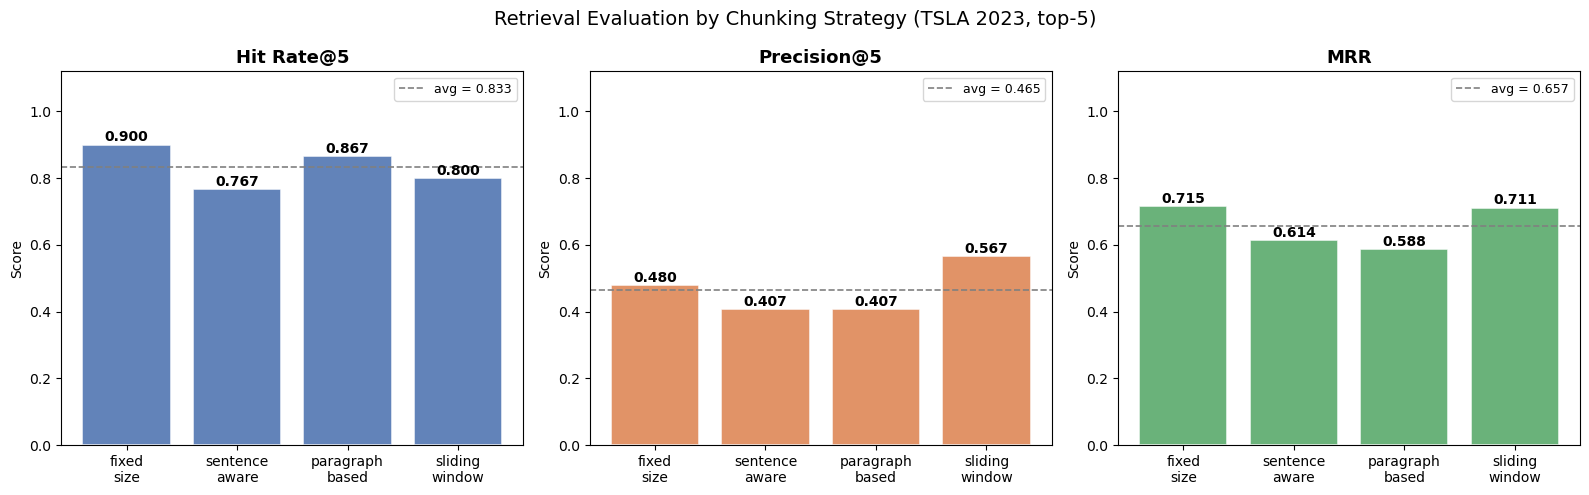

Saved: retrieval_metrics.png


In [20]:
# Bar chart: all three retrieval metrics side by side 
methods      = list(retrieval_results.keys())
method_labels = [m.replace("_", "\n") for m in methods]
palette = ["#4C72B0", "#DD8452", "#55A868"]
metric_keys   = ["hit_rate", "precision", "mrr"]
metric_labels = ["Hit Rate@5", "Precision@5", "MRR"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, m_key, m_label, color in zip(axes, metric_keys, metric_labels, palette):
    values = [retrieval_results[m][m_key] for m in methods]
    bars   = ax.bar(method_labels, values, color=color, alpha=0.88, edgecolor="white", linewidth=1.2)
    avg    = np.mean(values)
    ax.axhline(avg, color="gray", linestyle="--", linewidth=1.2, label=f"avg = {avg:.3f}")
    ax.set_title(m_label, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Retrieval Evaluation by Chunking Strategy (TSLA 2023, top-5)", fontsize=14)
plt.tight_layout()
plt.savefig("retrieval_metrics.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: retrieval_metrics.png")

In [21]:
# Breakdown by question difficulty 
print("Hit Rate@5 breakdown by difficulty:\n")
print(f"{'Method':<22}  {'easy':>7}  {'medium':>8}  {'hard':>7}")
print("─" * 52)
for method, res in retrieval_results.items():
    df_det = pd.DataFrame(res["details"])
    by_diff = df_det.groupby("difficulty")["hit"].mean()
    easy   = by_diff.get("easy",   float("nan"))
    medium = by_diff.get("medium", float("nan"))
    hard   = by_diff.get("hard",   float("nan"))
    print(f"{method:<22}  {easy:>7.3f}  {medium:>8.3f}  {hard:>7.3f}")

print()
# Identify failed retrievals
print("Questions with Hit Rate = 0 (failed retrieval):")
any_fail = False
for method, res in retrieval_results.items():
    fails = [d for d in res["details"] if d["hit"] == 0]
    if fails:
        any_fail = True
        for f in fails:
            q_obj = next(q for q in EVAL_QUESTIONS if q["id"] == f["question_id"])
            print(f"  [{method}]  {f['question_id']} ({f['difficulty']}): "
                  f"expected {f['expected']} → retrieved top-1 = {f['top1_section']}")
if not any_fail:
    print("  None! All questions had at least one relevant chunk in top-5.")

Hit Rate@5 breakdown by difficulty:

Method                     easy    medium     hard
────────────────────────────────────────────────────
fixed_size                0.900     0.800    1.000
sentence_aware            0.800     0.700    0.800
paragraph_based           1.000     0.700    0.900
sliding_window            0.800     0.700    0.900

Questions with Hit Rate = 0 (failed retrieval):
  [fixed_size]  q07 (easy): expected ['item_1'] → retrieved top-1 = item_8
  [fixed_size]  q14 (medium): expected ['item_7'] → retrieved top-1 = item_8
  [fixed_size]  q19 (medium): expected ['item_7'] → retrieved top-1 = item_8
  [sentence_aware]  q05 (easy): expected ['item_1'] → retrieved top-1 = item_8
  [sentence_aware]  q07 (easy): expected ['item_1'] → retrieved top-1 = item_8
  [sentence_aware]  q14 (medium): expected ['item_7'] → retrieved top-1 = item_8
  [sentence_aware]  q19 (medium): expected ['item_7'] → retrieved top-1 = item_8
  [sentence_aware]  q20 (medium): expected ['item_1'] → r

---
## 7. End-to-End Generation Evaluation

Now we put the full pipeline together: retrieve → generate → evaluate. For each combination of chunking strategy and generative model, we run all 15 evaluation questions through the complete pipeline and score the outputs.

**Faithfulness Score (Keyword Overlap):** For each question we have a manually defined list of key phrases that should appear in any correct, grounded answer. The faithfulness score is the fraction of those phrases found in the model's response. This is a practical proxy for the LLM-as-judge approach described in our proposal — a full GPT-4o judge would be more rigorous but significantly more expensive for an ablation over 4×3×15 = 180 calls. The keyword overlap still captures whether the model is including the right domain-specific terms.

**Relevance Score (Heuristic):** We check whether the answer cites its sources (using [1], [2] notation) and avoids outright refusals, giving a 0–1 score. This is a rough proxy for whether the answer is actually responsive to the question.

**Latency:** Wall-clock time from sending the query to receiving the full response.

In [22]:
def faithfulness_score(answer: str, key_phrases: list) -> float:
    """
    Fraction of expected key phrases found (case-insensitive) in the answer.
    Higher = model used more of the right terminology from the source documents.
    """
    if not key_phrases:
        return 0.0
    ans_lower = answer.lower()
    return sum(1 for kp in key_phrases if kp.lower() in ans_lower) / len(key_phrases)


def relevance_score(answer: str) -> float:
    """
    Heuristic relevance proxy:
    - Penalizes outright refusals or 'I don't know' responses
    - Rewards answers that include source citations ([1], [2], ...)
    - Caps at 1.0
    """
    refusals = [
        "i don't know", "cannot answer", "not enough information",
        "no information provided", "context does not contain",
        "insufficient information"
    ]
    ans_lower = answer.lower()
    if any(r in ans_lower for r in refusals):
        return 0.25  # honest refusal is not entirely wrong, but not useful either

    n_citations = len(re.findall(r"\[\d+\]", answer))
    score = min(1.0, 0.4 + n_citations * 0.12)
    return round(score, 3)


print("Evaluation functions defined.")

Evaluation functions defined.


In [23]:
# 4 chunking methods × 2 models × 30 questions = 240 generation calls
# Plus 240 LLM-judge calls (also GPT-4o-mini) = 480 API calls total

gen_results = {}  # key: (method_name, model_name) -> list of per-question dicts

for method_name, collection in collections.items():
    for model_name, gen_fn in GENERATORS.items():
        key   = (method_name, model_name)
        per_q = []
        print(f"\n★  {method_name}  ×  {model_name}")

        for q in EVAL_QUESTIONS:
            retrieved = retrieve_from_collection(collection, q["question"], k=TOP_K)
            context   = format_context(retrieved)

            answer, latency = gen_fn(q["question"], context)

            faith_kw    = faithfulness_keyword(answer, q["key_phrases"])
            faith_judge = llm_judge_faithfulness(q["question"], answer, context)
            relev       = relevance_score(answer)

            per_q.append({
                "question_id":        q["id"],
                "difficulty":         q["difficulty"],
                "faithfulness_kw":    faith_kw,
                "faithfulness_judge": faith_judge,
                "relevance":          relev,
                "latency_s":          latency,
                "answer":             answer,
            })
            print(f"  {q['id']} ({q['difficulty']:6s})  "
                  f"kw={faith_kw:.2f}  judge={faith_judge:.2f}  "
                  f"relev={relev:.2f}  {latency:.1f}s")

        gen_results[key] = per_q

print("\n\n Generation evaluation complete.")


★  fixed_size  ×  Ollama
  q01 (easy  )  kw=1.00  judge=1.00  relev=0.64  13.0s
  q02 (easy  )  kw=0.80  judge=1.00  relev=1.00  7.5s
  q03 (easy  )  kw=0.60  judge=0.30  relev=0.76  8.0s
  q04 (easy  )  kw=1.00  judge=1.00  relev=0.64  8.2s
  q05 (easy  )  kw=1.00  judge=1.00  relev=0.64  6.5s
  q06 (easy  )  kw=0.80  judge=1.00  relev=0.52  5.8s
  q07 (easy  )  kw=1.00  judge=0.70  relev=0.88  7.1s
  q08 (easy  )  kw=0.80  judge=1.00  relev=0.88  6.3s
  q09 (easy  )  kw=0.80  judge=0.70  relev=0.40  6.4s
  q10 (easy  )  kw=0.80  judge=0.70  relev=0.88  8.4s
  q11 (medium)  kw=0.80  judge=0.30  relev=0.52  7.8s
  q12 (medium)  kw=0.75  judge=0.70  relev=0.88  7.7s
  q13 (medium)  kw=0.60  judge=1.00  relev=0.64  8.4s
  q14 (medium)  kw=0.80  judge=0.30  relev=0.88  5.7s
  q15 (medium)  kw=0.80  judge=0.70  relev=0.52  6.1s
  q16 (medium)  kw=0.80  judge=0.50  relev=0.52  7.8s
  q17 (medium)  kw=0.60  judge=0.30  relev=0.76  7.3s
  q18 (medium)  kw=1.00  judge=1.00  relev=0.40  7.5s
 

### Results Summary Table

We now aggregate the per-question scores into method × model averages and merge in the retrieval metrics to get one unified table.

In [24]:
# Build summary DataFrame
rows = []
for (method, model), per_q in gen_results.items():
    df_q = pd.DataFrame(per_q)
    ret  = retrieval_results.get(method, {})
    rows.append({
        "Chunking":            method.replace("_", " ").title(),
        "Model":               model,
        "Hit Rate@5":          ret.get("hit_rate", float("nan")),
        "MRR":                 ret.get("mrr", float("nan")),
        "Faith (LLM-Judge)":   round(df_q["faithfulness_judge"].mean(), 3),
        "Faith (Keyword)": round(df_q["faithfulness_kw"].mean(), 3),
        "Relevance":           round(df_q["relevance"].mean(), 3),
        "Latency (s)":         round(df_q["latency_s"].mean(), 2),
    })

df_summary = (
    pd.DataFrame(rows)
    .sort_values("Faith (LLM-Judge)", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print("Full Evaluation Results (sorted by LLM-Judge Faithfulness ↓):")
print()
print(df_summary.to_string(index=False))

Full Evaluation Results (sorted by LLM-Judge Faithfulness ↓):

       Chunking  Model  Hit Rate@5   MRR  Faith (LLM-Judge)  Faith (Keyword)  Relevance  Latency (s)
 Sentence Aware OpenAI       0.767 0.614              0.773            0.785      0.905        7.710
Paragraph Based OpenAI       0.867 0.588              0.747            0.803      0.980        6.000
 Sliding Window OpenAI       0.800 0.711              0.720            0.792      0.988        5.000
 Sliding Window Ollama       0.800 0.711              0.710            0.717      0.760        6.630
     Fixed Size OpenAI       0.900 0.715              0.683            0.818      0.963        6.260
 Sentence Aware Ollama       0.767 0.614              0.647            0.758      0.636        7.680
     Fixed Size Ollama       0.900 0.715              0.630            0.792      0.736        7.570
Paragraph Based Ollama       0.867 0.588              0.623            0.703      0.704        7.230


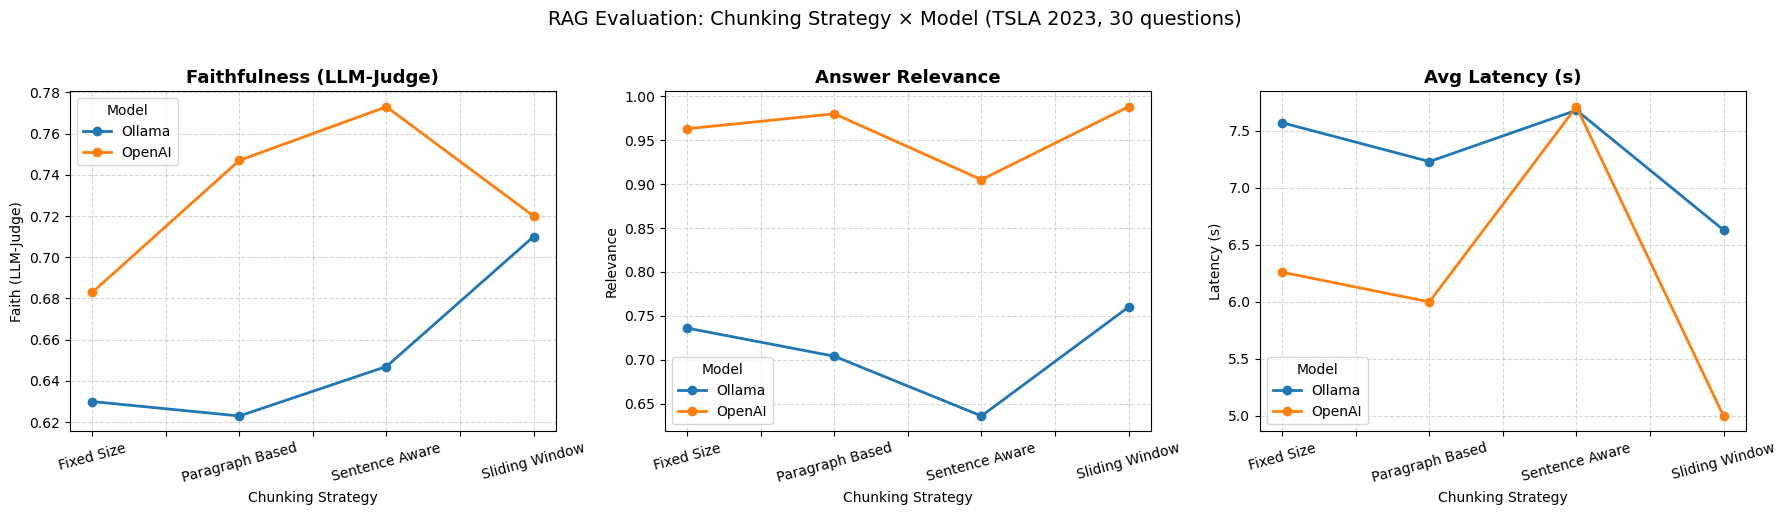

Saved: evaluation_lineplot_v2.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["Faith (LLM-Judge)", "Relevance", "Latency (s)"]
titles  = ["Faithfulness (LLM-Judge)", "Answer Relevance", "Avg Latency (s)"]

for ax, metric, title in zip(axes, metrics, titles):
    pivot = df_summary.pivot_table(index="Chunking", columns="Model", values=metric)
    pivot.plot(ax=ax, marker="o", linewidth=2)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Chunking Strategy")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle(
    "RAG Evaluation: Chunking Strategy × Model (TSLA 2023, 30 questions)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig("evaluation_lineplot_v2.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: evaluation_lineplot_v2.png")

---
## 9. Cumulative Faithfulness Improvement Across Questions

**This section directly addresses the lecturer's request for a line chart showing how the model improves over multiple questions.**

Since questions are ordered **Easy (Q01–Q10) → Medium (Q11–Q20) → Hard (Q21–Q30)**, the cumulative average faithfulness shows:
- How well each chunking strategy handles increasing question difficulty
- Whether the advantage of Sliding Window is consistent across all difficulty levels
- At what point (which question number) weaker chunking strategies start to fall behind

The shaded regions mark the three difficulty zones. A strategy that **maintains a high cumulative average through the hard zone** is genuinely robust.

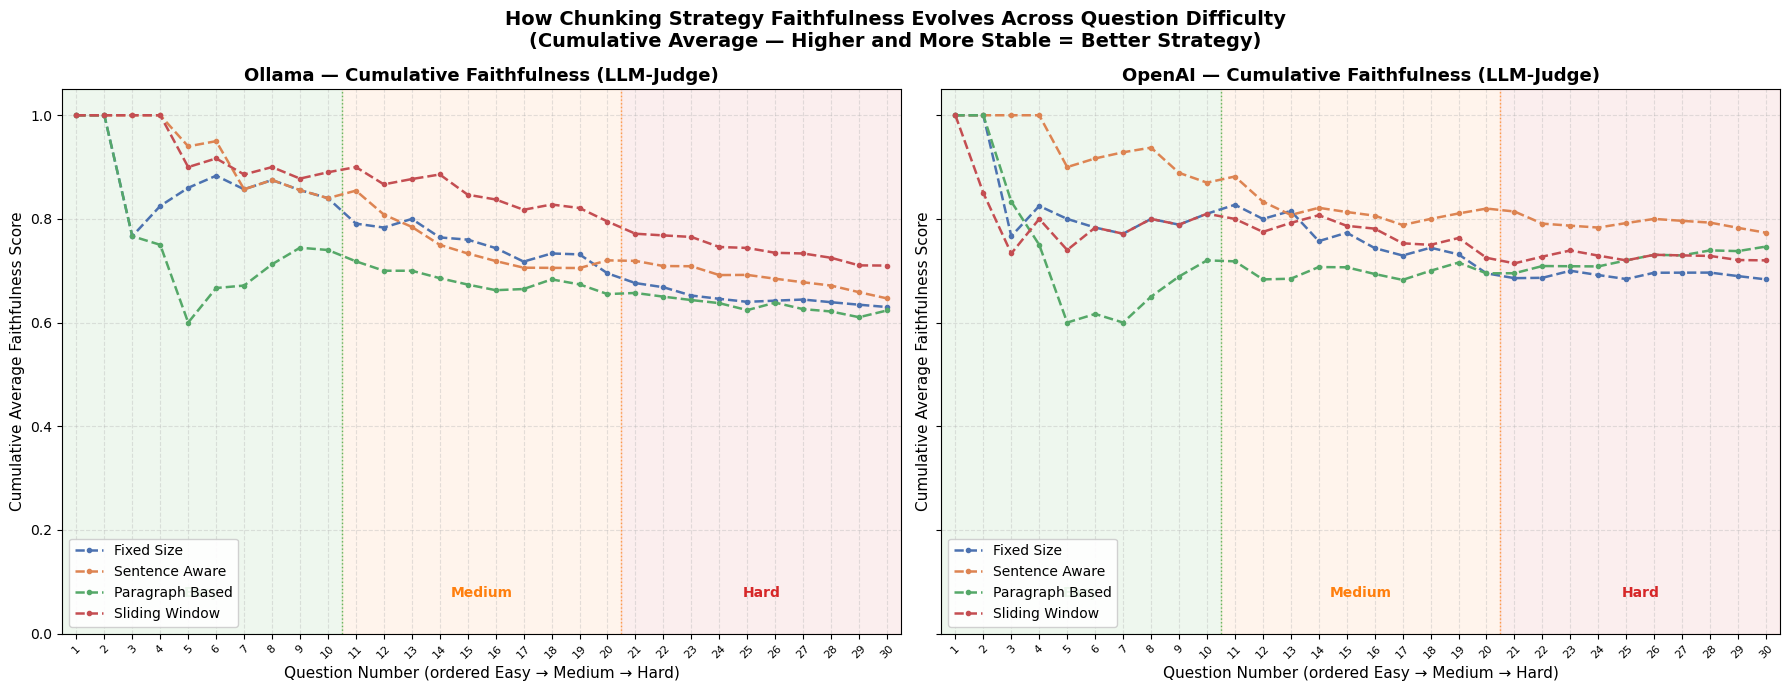

Saved: cumulative_faithfulness_improvement.png


In [29]:
METHOD_COLORS = {
    "fixed_size":      "#4C72B0",
    "sentence_aware":  "#DD8452",
    "paragraph_based": "#55A868",
    "sliding_window":  "#C44E52",
}

n_easy   = sum(1 for q in EVAL_QUESTIONS if q["difficulty"] == "easy")
n_medium = sum(1 for q in EVAL_QUESTIONS if q["difficulty"] == "medium")
n_hard   = sum(1 for q in EVAL_QUESTIONS if q["difficulty"] == "hard")
n_total  = len(EVAL_QUESTIONS)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, model_name in zip(axes, ["Ollama", "OpenAI"]):

    # Difficulty zone shading
    ax.axvspan(0.5, n_easy + 0.5,                    alpha=0.08, color="#2ca02c", label="_easy_zone")
    ax.axvspan(n_easy + 0.5, n_easy + n_medium + 0.5, alpha=0.08, color="#ff7f0e", label="_med_zone")
    ax.axvspan(n_easy + n_medium + 0.5, n_total + 0.5, alpha=0.08, color="#d62728", label="_hard_zone")

    # Boundary lines
    ax.axvline(n_easy + 0.5,          color="#2ca02c", linestyle=":", linewidth=1, alpha=0.7)
    ax.axvline(n_easy + n_medium + 0.5, color="#ff7f0e", linestyle=":", linewidth=1, alpha=0.7)

    for method in CHUNKERS:
        key = (method, model_name)
        if key not in gen_results:
            continue
        faith_list  = [r["faithfulness_judge"] for r in gen_results[key]]
        n           = len(faith_list)
        cumulative  = np.cumsum(faith_list) / np.arange(1, n + 1)
        label = method.replace("_", " ").title()
        ax.plot(
            range(1, n + 1), cumulative,
            color=METHOD_COLORS[method], label=label,
            linewidth=1.8, linestyle="--", marker="o", markersize=3, zorder=3
        )

    # Difficulty zone labels
    ax.text(n_easy / 2 + 0.5,       0.07, "Easy",   ha="center", fontsize=10, color="#2ca02c", fontweight="bold")
    ax.text(n_easy + n_medium / 2 + 0.5, 0.07, "Medium", ha="center", fontsize=10, color="#ff7f0e", fontweight="bold")
    ax.text(n_easy + n_medium + n_hard / 2 + 0.5, 0.07, "Hard", ha="center", fontsize=10, color="#d62728", fontweight="bold")

    ax.set_title(f"{model_name} — Cumulative Faithfulness (LLM-Judge)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Question Number (ordered Easy → Medium → Hard)", fontsize=11)
    ax.set_ylabel("Cumulative Average Faithfulness Score", fontsize=11)
    ax.set_xlim(0.5, n_total + 0.5)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(range(1, n_total + 1))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=10, loc="lower left", framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)

plt.suptitle(
    "How Chunking Strategy Faithfulness Evolves Across Question Difficulty\n"
    "(Cumulative Average — Higher and More Stable = Better Strategy)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("cumulative_faithfulness_improvement.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: cumulative_faithfulness_improvement.png")

In [30]:
# Final end-of-hard-zone score: cumulative faithfulness at question 30
# This summarizes: "after seeing all questions, which strategy + model was best?"

print("Cumulative faithfulness at Q30 (LLM-Judge — full 30-question run):")
print()
print(f"{'Chunking Method':<22}  {'Ollama':>8}  {'OpenAI':>8}  {'Δ (OAI-Ollama)':>15}")
print("─" * 60)

for method in CHUNKERS:
    ollama_key = (method, "Ollama")
    openai_key = (method, "OpenAI")

    def final_cum(key):
        if key not in gen_results:
            return float("nan")
        scores = [r["faithfulness_judge"] for r in gen_results[key]]
        return round(np.mean(scores), 3)

    ol = final_cum(ollama_key)
    oa = final_cum(openai_key)
    delta = round(oa - ol, 3) if not np.isnan(ol) and not np.isnan(oa) else float("nan")
    print(f"{method:<22}  {ol:>8.3f}  {oa:>8.3f}  {delta:>+15.3f}")

Cumulative faithfulness at Q30 (LLM-Judge — full 30-question run):

Chunking Method           Ollama    OpenAI   Δ (OAI-Ollama)
────────────────────────────────────────────────────────────
fixed_size                 0.630     0.683           +0.053
sentence_aware             0.647     0.773           +0.126
paragraph_based            0.623     0.747           +0.124
sliding_window             0.710     0.720           +0.010


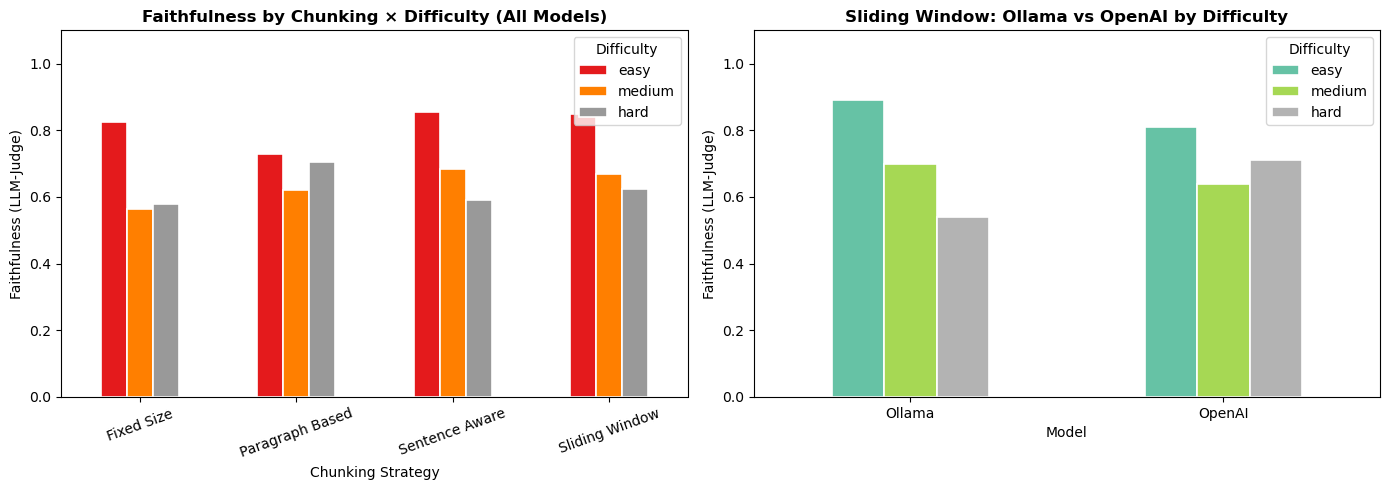

Saved: faithfulness_by_difficulty_v2.png


In [31]:
# Faithfulness by difficulty level — shows exactly where each strategy degrades
diff_rows = []
for (method, model), per_q in gen_results.items():
    for entry in per_q:
        diff_rows.append({
            "Chunking":   method.replace("_", " ").title(),
            "Model":      model,
            "difficulty": entry["difficulty"],
            "faith_judge": entry["faithfulness_judge"],
        })

df_diff = pd.DataFrame(diff_rows)
pivot_diff = (
    df_diff.groupby(["Chunking", "difficulty"])["faith_judge"]
    .mean()
    .unstack()
    .reindex(columns=["easy", "medium", "hard"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all models combined
pivot_diff.plot(kind="bar", ax=axes[0], colormap="Set1", edgecolor="white", linewidth=1.2)
axes[0].set_title("Faithfulness by Chunking × Difficulty (All Models)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Faithfulness (LLM-Judge)")
axes[0].set_xlabel("Chunking Strategy")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Difficulty")
axes[0].set_ylim(0, 1.1)

# Right: sliding window only — compare Ollama vs OpenAI per difficulty
sw_data = df_diff[df_diff["Chunking"] == "Sliding Window"]
sw_pivot = (
    sw_data.groupby(["Model", "difficulty"])["faith_judge"]
    .mean()
    .unstack()
    .reindex(columns=["easy", "medium", "hard"])
)
sw_pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white", linewidth=1.2)
axes[1].set_title("Sliding Window: Ollama vs OpenAI by Difficulty",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Faithfulness (LLM-Judge)")
axes[1].set_xlabel("Model")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Difficulty")
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("faithfulness_by_difficulty_v2.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: faithfulness_by_difficulty_v2.png")

---
## 8. Summary, Key Findings & Future Work

We wrap up by identifying the best-performing configuration and discussing what the results tell us about the research question.

In [37]:
print("=" * 60)
print("BEST CONFIGURATION")
print("=" * 60)

if len(df_summary) > 0:
    best = df_summary.sort_values("Faith (LLM-Judge)", ascending=False).iloc[0]
    print(f"Chunking Strategy   : {best['Chunking']}")
    print(f"Generative Model    : {best['Model']}")
    print(f"Faithfulness (Judge): {best['Faith (LLM-Judge)']:.3f}")
    print(f"Faithfulness (KW)   : {best['Faith (Keyword)']:.3f}")
    print(f"Relevance           : {best['Relevance']:.3f}")
    print(f"Hit Rate@5          : {best['Hit Rate@5']:.3f}")
    print(f"MRR                 : {best['MRR']:.3f}")
    print(f"Avg Latency         : {best['Latency (s)']:.2f}s")


BEST CONFIGURATION
Chunking Strategy   : Sentence Aware
Generative Model    : OpenAI
Faithfulness (Judge): 0.773
Faithfulness (KW)   : 0.785
Relevance           : 0.905
Hit Rate@5          : 0.767
MRR                 : 0.614
Avg Latency         : 7.71s
